<a href="https://colab.research.google.com/github/navinabalab2007-ux/titanic/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt



In [3]:
df=pd.read_csv("train_and_test2.csv")

In [4]:
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.1

In [6]:
df.isnull().sum()

,0
Passengerid,0
Age,0
Fare,0
Sex,0
sibsp,0
zero,0
zero.1,0
zero.2,0
zero.3,0
zero.4,0


In [16]:
df.rename(columns={"2urvived":"survived"},inplace=True)

In [17]:
z_col=[col for col in df.columns if 'zero'in col]
df.drop(columns=z_col,inplace=True)
df.head()

,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,survived
0,22.0,7.2500,0,1,0,3,2.0,0
1,38.0,71.2833,1,1,0,1,0.0,1
2,26.0,7.9250,1,0,0,3,2.0,1
3,35.0,53.1000,1,1,0,1,2.0,1
4,35.0,8.0500,0,0,0,3,2.0,0


In [18]:
df.columns

Index(['Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked',
       'survived'],
      dtype='object')

In [19]:
df["Embarked"].fillna(df["Embarked"].mode()[0],inplace=True)

/tmp/ipykernel_2063/548196730.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0],inplace=True)


In [49]:
# Family size
df['FamilySize'] = df['sibsp'] + df['Parch'] + 1

# Is alone
df['IsAlone'] = 1
df.loc[df['FamilySize'] > 1, 'IsAlone'] = 0

In [54]:
cols=list(df.columns)
cols.remove("survived")
df=df[cols+["survived"]]

In [55]:
df.head()

,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,FamilySize,IsAlone,survived
0,22.0,7.2500,0,1,0,3,2.0,2,0,0
1,38.0,71.2833,1,1,0,1,0.0,2,0,1
2,26.0,7.9250,1,0,0,3,2.0,1,1,1
3,35.0,53.1000,1,1,0,1,2.0,2,0,1
4,35.0,8.0500,0,0,0,3,2.0,1,1,0


In [56]:
X=df.drop('survived',axis=1)
y=df["survived"]

In [57]:
s=StandardScaler()
X=s.fit_transform(X)

In [58]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [59]:
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [60]:
y_pred=model.predict(X_test)

In [61]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.816793893129771


In [62]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[186  16]
 [ 32  28]]


In [66]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.92      0.89       202
           1       0.64      0.47      0.54        60

    accuracy                           0.82       262
   macro avg       0.74      0.69      0.71       262
weighted avg       0.80      0.82      0.81       262



In [63]:
r_model = RandomForestClassifier(n_estimators=100)
r_model.fit(X_train, y_train)

r_pred = r_model.predict(X_test)

In [64]:
r_accuracy = accuracy_score(y_test, r_pred)

print("Random Forest Accuracy:", r_accuracy)


Random Forest Accuracy: 0.7633587786259542


In [65]:
print("Confusion Matrix:\n", confusion_matrix(y_test, r_pred))

Confusion Matrix:
 [[166  36]
 [ 26  34]]


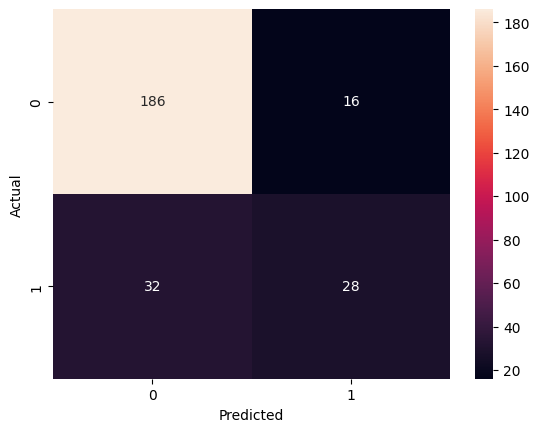

In [68]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [69]:
import joblib

joblib.dump(model, 'titanic_model.pkl')

['titanic_model.pkl']